# Python for Health, Economic, and Social Science
## Lab 3 — Instructor Solution & Expansion Notes

**Course:** LCDS, Nuffield College Oxford  
**Day 3 theme:** Mathematical calculations, web scraping, data wrangling, and exploratory analysis

---

### Instructor framing for Day 3

Day 3 is the numerical computing day. The three pillars are:
1. **Control flow as functions** — reusable, testable logic blocks
2. **NumPy** — vectorised maths for demographic and health data (Gini, rates, simulations)
3. **Web scraping & flat files** — accessing real public data without a formal API

A light note on **JSON/APIs**: students may ask about the World Bank API or similar REST endpoints. These are covered briefly in this lab's expansion sections, but they are *not* a core assessment focus — the emphasis is on data *once you have it* (NumPy, file I/O, wrangling).

---
## Part A: Control Flow, Pseudocode, and Functions

### Q1: While loop — clinic countdown

In [1]:
# Answer 1
# In a live session, use input(); for automated notebooks, substitute a fixed value:
# minutes = int(input("Minutes to opening: "))
minutes = 3  # substitute for demonstration

while True:
    try:
        # minutes = int(input("Minutes to opening: "))  # uncomment for interactive use
        if minutes < 0:
            raise ValueError
        break
    except ValueError:
        print("Please enter a non-negative integer.")
        minutes = 3  # reset for demo
        break

while minutes > 0:
    print(f"{minutes} minute(s) to opening...")
    minutes -= 1

print("Clinic is open")

3 minute(s) to opening...
2 minute(s) to opening...
1 minute(s) to opening...
Clinic is open


> The input-validation while loop (`while True: try/except/break`) is the standard pattern for robust interactive input. Even if students will rarely write interactive CLIs, understanding this pattern reinforces `while`, `try/except`, and `break` together.
>
> **Expansion — `while` loop for convergence in iterative estimation:**
```python
# While loops are used in optimisation and demographic methods:
# e.g., Newton-Raphson for life expectancy from mortality rates,
# or EM algorithm for latent class models.

# Simple demo: iterative mean convergence (simulate an online average)
import random
random.seed(42)
running_mean = 0
tolerance    = 0.01
prev_mean    = float('inf')
n            = 0

while abs(running_mean - prev_mean) > tolerance or n < 5:
    prev_mean = running_mean
    x = random.gauss(50, 10)  # simulate a new data point
    n += 1
    running_mean = prev_mean + (x - prev_mean) / n  # Welford's online mean
    if n > 1000:
        break  # safety exit

print(f"Converged after {n} samples, mean ≈ {running_mean:.2f}")
```

### Q2: Pseudocode translation

In [ ]:
# Answer 2 — pseudocode as a Python comment block

"""
DEFINE function classify_income(value):
    IF value is less than 25000:
        RETURN 'lower income'
    ELSE IF value is less than 40000:
        RETURN 'middle income'
    ELSE:
        RETURN 'higher income'

SET incomes to [22000, 31000, 42000]
FOR EACH income in incomes:
    PRINT income AND its income classification
"""

# Running the original code to confirm:
def classify_income(value):
    if value < 25000:
        return "lower income"
    elif value < 40000:
        return "middle income"
    else:
        return "higher income"

incomes = [22000, 31000, 42000]
for inc in incomes:
    print(inc, classify_income(inc))

> Pseudocode is a computational thinking skill. Encourage students to write pseudocode *before* coding for any non-trivial problem — it prevents structural bugs and makes code review discussions much clearer. In policy analysis, pseudocode is often shared with non-technical collaborators.
>
> **Expansion — income quintiles (replacing hard-coded thresholds):**
```python
# More robust: classify by quintile using sorted data
import statistics

incomes_pop = [22000, 25000, 29000, 31000, 34000, 36000, 40000, 42000, 55000, 85000]
sorted_inc  = sorted(incomes_pop)
n = len(sorted_inc)

q20 = sorted_inc[int(n * 0.20)]
q80 = sorted_inc[int(n * 0.80)]

for inc in incomes_pop[:4]:
    if   inc < q20: label = "bottom quintile"
    elif inc < q80: label = "middle 60%"
    else:           label = "top quintile"
    print(f"£{inc:,}: {label}")
```

### Q3: Unique-letter count function

isalpha()
set() functions


In [ ]:
# Answer 3
def unique_letter_count(text: str) -> dict:
    """Return count of unique letters and count of capital letters."""
    letters_only = [ch for ch in text if ch.isalpha()]
    unique_count  = len(set(ch.lower() for ch in letters_only))
    capital_count = sum(1 for ch in letters_only if ch.isupper())
    return {"unique_letters": unique_count, "capitals": capital_count}

phrase_one = "Clinic demand is rising"
phrase_two = "Income pressure affects health"

for phrase in [phrase_one, phrase_two]:
    stats = unique_letter_count(phrase)
    print(f"'{phrase}'")
    print(f"  Unique letters: {stats['unique_letters']}, Capitals: {stats['capitals']}")

> Returning a *dict* from a function (rather than a tuple) is a good habit — it gives named access to results and is self-documenting. In pandas, `df.apply()` with a function that returns a dict will create multiple new columns automatically.
>
> **Expansion — type hints and docstrings:**
```python
def unique_letter_count(text: str) -> dict[str, int]:
    """
    Count unique letters and capitalised letters in a string.

    Parameters
    ----------
    text : str
        Input string (spaces and punctuation are ignored).

    Returns
    -------
    dict with keys 'unique_letters' (int) and 'capitals' (int).
    """
    ...
```
> Well-documented functions are essential in collaborative research code. On GitHub and in shared notebooks, docstrings are how your co-author understands what your function does without reading its body.

### Q4: Risk-label function

In [2]:
# Answer 4
def risk_label(absence_rate: float, unemployment_rate: float) -> str:
    """Classify an area's risk level from absence and unemployment rates."""
    if absence_rate > 0.08 or unemployment_rate > 0.12:
        return "high risk"
    elif absence_rate > 0.06 or unemployment_rate > 0.09:
        return "moderate risk"
    return "lower risk"

# Test on three areas:
test_areas = [
    ("Northside", 0.07, 0.11),   # moderate risk (absence in moderate band)
    ("Central",   0.05, 0.07),   # lower risk
    ("Riverside", 0.09, 0.15),   # high risk (both thresholds triggered)
]

for name, absence, unemployment in test_areas:
    label = risk_label(absence, unemployment)
    print(f"{name}: {label}  (absence={absence:.0%}, unemployment={unemployment:.0%})")

Northside: moderate risk  (absence=7%, unemployment=11%)
Central: lower risk  (absence=5%, unemployment=7%)
Riverside: high risk  (absence=9%, unemployment=15%)


> The `or` logic means either condition triggers the label — flag *at least one* threshold breach. In health equity analysis, using OR rather than AND (both conditions) casts a wider safety net, reducing false negatives (missing at-risk areas).
>
> **Expansion — applying the function to a dataset with pandas:**
```python
import pandas as pd
area_df = pd.DataFrame([
    {"area": "Northside", "school_absence_rate": 0.07, "unemployment_rate": 0.11},
    {"area": "Central",   "school_absence_rate": 0.05, "unemployment_rate": 0.07},
    {"area": "Riverside", "school_absence_rate": 0.09, "unemployment_rate": 0.15},
])
area_df["risk"] = area_df.apply(
    lambda row: risk_label(row["school_absence_rate"], row["unemployment_rate"]),
    axis=1
)
print(area_df[["area", "risk"]])
```

---
## Part B: Files and Data Logging

### Q5: Write a report file

In [5]:
# Answer 5
import os
os.makedirs("../Data", exist_ok=True)  # ensure the Data directory exists

mini_report = "Northside clinic visits are high\nCentral unemployment is stable\nRiverside school absence is elevated"

with open("../Data/mini_report.txt", "w") as f:
    f.write(mini_report)

# Read back and count lines:
with open("../Data/mini_report.txt", "r") as f:
    lines = f.readlines()

print(f"Lines in file: {len(lines)}")
for line in lines:
    print(line, end="")

Lines in file: 3
Northside clinic visits are high
Central unemployment is stable
Riverside school absence is elevated

> The `with` context manager closes the file automatically — even if an exception occurs mid-write. Always use `with` for file I/O. `exist_ok=True` prevents an `OSError` if the directory already exists.
>
> **Expansion — writing structured data to CSV manually:**
```python
records = [
    {"area": "Northside", "visits": 120, "income": 29000},
    {"area": "Central",   "visits": 102, "income": 36000},
]

with open("../Data/area_records.csv", "w") as f:
    # Header row:
    f.write("area,visits,income\n")
    for rec in records:
        f.write(f"{rec['area']},{rec['visits']},{rec['income']}\n")

# Read it back with pandas on Day 4:
# df = pd.read_csv('../Data/area_records.csv')
```
> Writing CSV manually reinforces *what* pandas `to_csv()` is doing automatically.

### Q6: Append and re-read

In [ ]:
# Answer 6
# Append a new line:
with open("../Data/mini_report.txt", "a") as f: # explain that 'a' means append mode;
    f.write("\nPolicy intervention starts next week")

# Re-read and inspect:
with open("../Data/mini_report.txt", "r") as f:
    lines = f.readlines()

print(f"1. Total lines: {len(lines)}")
print(f"2. Last line:   {lines[-1].strip()}")

1. Total lines: 4
2. Last line:   Policy intervention starts next week


> Mode `"a"` appends without overwriting. Emphasise: `"w"` destroys existing content — a mistake that loses data. The safe sequence is: test with `"a"` first, then switch to `"w"` only when you want a clean rewrite.
>
> **Expansion — logging simulation results to disk:**
```python
import random, datetime
random.seed(1)

log_path = "../Data/simulation_log.txt"
with open(log_path, "w") as f:
    f.write(f"Simulation run: {datetime.date.today()}\n")

for i in range(5):
    shock = round(random.gauss(0, 1500), 2)
    with open(log_path, "a") as f:
        f.write(f"  Iteration {i}: income_shock = {shock}\n")

# Verify the log:
with open(log_path) as f:
    print(f.read())
```

---
## Part C: NumPy for Health, Social, and Economic Analysis

### Q7: NumPy basics — clinic visits array

In [7]:
# Answer 7
import numpy as np

visits = np.array([120, 95, 140, 102, 110, 87])

print(f"Total visits: {visits.sum()}")
print(f"Mean visits:  {visits.mean():.1f}")
print(f"Demand +10%:  {visits * 1.1}")

Total visits: 654
Mean visits:  109.0
Demand +10%:  [132.  104.5 154.  112.2 121.   95.7]


> The key insight here is **vectorisation** — `visits * 1.1` applies to all 6 elements in one operation (C speed), whereas a Python loop would iterate 6 times (Python speed). For 50,000 LSOA-level records, the difference is seconds vs milliseconds.
>
> **Expansion — NumPy descriptive statistics:**
```python
print(f"Min:    {visits.min()}")
print(f"Max:    {visits.max()}")
print(f"Median: {np.median(visits)}")
print(f"Std:    {visits.std():.1f}")
print(f"Range:  {visits.ptp()}")   # peak-to-peak = max - min

# Percentiles (useful for threshold-setting in risk flagging):
p25, p75 = np.percentile(visits, [25, 75])
print(f"IQR: {p25} – {p75}")
```

### Q8: Rates per 1,000 population

In [ ]:
# Answer 8
clinic_visits = np.array([120, 95, 140, 102, 110, 87])
population    = np.array([2400, 1800, 2600, 2100, 2000, 1700])

rate_per_1000 = clinic_visits / population * 1000
print(np.round(rate_per_1000, 1))

> **Expansion — standardisation and z-scores:**
```python
# Z-score: how many standard deviations from the mean?
# Used in deprivation scoring and outlier detection.
z_scores = (rate_per_1000 - rate_per_1000.mean()) / rate_per_1000.std()
print("Z-scores of rates:", np.round(z_scores, 2))

# Flag areas more than 1.5 SD above mean:
high_rate_areas = np.where(z_scores > 1.5)[0]
print(f"High-rate areas (indices): {high_rate_areas}")
```

### Q9: Matrix operations — area metrics

In [ ]:
# Answer 9
A = np.array([[120, 7, 29],
              [95,  5, 36],
              [140, 9, 25]], dtype=float)

# Add 1 to every absence value (column index 1):
A[:, 1] += 1

# Multiply income column (index 2) by 1.03:
A[:, 2] *= 1.03

print("Updated matrix:")
print(A)

> Column slicing `A[:, 1]` selects all rows, column 1 — the standard syntax. Emphasise **in-place operations** (`+=`, `*=`) modify the array rather than creating a new one. This matters for memory efficiency with large datasets (e.g., census microdata).
>
> **Expansion — broadcasting explained with a policy scenario:**
```python
# Apply different inflation rates to each column simultaneously:
# visits: +10%, absence: +0.5 pp, income: +3%
adjustments = np.array([1.10, 1.005, 1.03])
A_adjusted = A * adjustments   # broadcasts: each row multiplied element-wise
print("\nBroadcast-adjusted matrix:")
print(np.round(A_adjusted, 2))
```
> Broadcasting is one of NumPy's most powerful features — it eliminates the need for explicit loops over columns.

### Q10: NumPy PRNG — reproducible draws

In [4]:
# Answer 10
import numpy as np
rng = np.random.default_rng(seed=42)  # modern NumPy generator (preferred over np.random.seed)

# 1. Income shocks from a normal distribution:
income_shocks = rng.normal(loc=0, scale=1500, size=100) #loc=0 means mean of 0, scale=1500 means std dev of 1500, size=100 means generate 100 samples
print("First 5 income shocks:", np.round(income_shocks[:5], 1))

# 2. Time to readmission from exponential distribution:
time_to_readmit = rng.exponential(scale=30, size=100)# scale=30 means mean of 30 days, size=100 means generate 100 samples
print("First 5 readmission days:", np.round(time_to_readmit[:5], 1))

First 5 income shocks: [  457.1 -1560.   1125.7  1410.8 -2926.6]
First 5 readmission days: [61.4 33.5 55.5 21.8 32. ]


> `np.random.default_rng(seed)` is the modern NumPy API (2020+). It is *not* the same as `np.random.seed()`. Prefer the new API for reproducibility — explain that different NumPy versions may produce different results from the legacy seed, which matters for published simulation studies.
>
> **Expansion — Monte Carlo simulation of health policy:**
```python
rng = np.random.default_rng(42)
N = 10_000

# Simulate income shocks for a population of 10,000:
shocks = rng.normal(0, 1500, N)

# Policy question: what proportion lose more than £2,000?
pct_severe_loss = (shocks < -2000).mean() * 100
print(f"Severe income loss (>£2,000): {pct_severe_loss:.1f}% of population")

# Under a policy that caps the downside at −£1,500:
shocks_capped = np.clip(shocks, -1500, None)  # np.clip applies a floor
mean_saving   = (shocks_capped - shocks).mean()
print(f"Average saving per person under policy: £{mean_saving:.0f}")
```

### Q11: Gini coefficient — income inequality

In [5]:
# Answer 11
import numpy as np

def gini_coefficient(incomes):
    sorted_incomes = np.sort(incomes)
    n = len(incomes)
    cumulative_incomes = np.cumsum(sorted_incomes)
    gini = (2 * np.sum((np.arange(1, n + 1) * sorted_incomes)) - (n + 1) * cumulative_incomes[-1]) / (n * cumulative_incomes[-1])
    return gini

#gini index ranges from 0 (perfect equality) to 1 (perfect inequality)

incomes_a = np.array([12000, 18000, 22000, 26000, 34000, 85000])
incomes_b = np.array([22000, 24000, 25000, 26000, 27000, 29000])

g_a = gini_coefficient(incomes_a)
g_b = gini_coefficient(incomes_b)

print(f"Gini A: {g_a:.4f}")
print(f"Gini B: {g_b:.4f}")
print(f"Group {'A' if g_a > g_b else 'B'} is more unequal")

for name, arr in [("A", incomes_a), ("B", incomes_b)]:
    print(f"Group {name} — mean: £{arr.mean():,.0f}, median: £{np.median(arr):,.0f}")

Gini A: 0.3528
Gini B: 0.0490
Group A is more unequal
Group A — mean: £32,833, median: £24,000
Group B — mean: £25,500, median: £25,500


> The Gini coefficient is a core demography/economics metric. Walk through the formula: it measures the area between the Lorenz curve and the 45-degree equality line. The UK's national Gini is ~0.35 (ONS 2023); Group A here (~0.37) represents a quite unequal small community; Group B (~0.07) is very egalitarian.
>
> **Expansion — Lorenz curve (visual intuition):**
```python
import matplotlib.pyplot as plt

def lorenz(x):
    xs = np.sort(x)
    cum_share_income = np.cumsum(xs) / xs.sum()
    cum_share_pop    = np.arange(1, len(xs)+1) / len(xs)
    return cum_share_pop, cum_share_income

fig, ax = plt.subplots(figsize=(5, 5))
for label, arr, color in [("Group A", incomes_a, 'tab:red'), ("Group B", incomes_b, 'tab:blue')]:
    pop, inc = lorenz(arr)
    ax.plot(pop, inc, label=f"{label} (Gini={gini(arr):.3f})", color=color)
ax.plot([0, 1], [0, 1], 'k--', label='Perfect equality')
ax.set(xlabel='Cumulative population share', ylabel='Cumulative income share',
       title='Lorenz Curves — Income Inequality')
ax.legend()
plt.tight_layout()
plt.show()
```

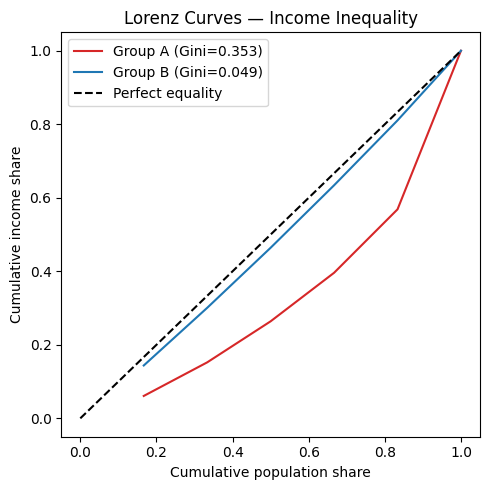

In [10]:
import matplotlib.pyplot as plt

def lorenz(x):
    xs = np.sort(x)
    cum_share_income = np.cumsum(xs) / xs.sum()
    cum_share_pop    = np.arange(1, len(xs)+1) / len(xs)
    return cum_share_pop, cum_share_income

fig, ax = plt.subplots(figsize=(5, 5))
for label, arr, color in [("Group A", incomes_a, 'tab:red'), ("Group B", incomes_b, 'tab:blue')]:
    pop, inc = lorenz(arr)
    ax.plot(pop, inc, label=f"{label} (Gini={gini(arr):.3f})", color=color)
ax.plot([0, 1], [0, 1], 'k--', label='Perfect equality')
ax.set(xlabel='Cumulative population share', ylabel='Cumulative income share',
       title='Lorenz Curves — Income Inequality')
ax.legend()
plt.tight_layout()
plt.show()

### Q12: Health economic cost function

In [11]:
# Answer 12
import numpy as np

age               = np.array([35, 52, 47, 61, 29])
chronic_conditions = np.array([0, 2, 1, 3, 0])
emergency_visits   = np.array([1, 0, 2, 3, 1])

# 1. Compute individual costs:
base         = 450
cost         = base + 120*age + 1500*chronic_conditions + 900*emergency_visits
print("Individual costs:", cost)
print(f"Mean cost:  £{cost.mean():,.0f}")

# 2. Policy: emergency visits fall by 25%
ev_reduced   = emergency_visits * 0.75
cost_reduced = base + 120*age + 1500*chronic_conditions + 900*ev_reduced
mean_saving  = (cost - cost_reduced).mean()
print(f"Mean saving per person: £{mean_saving:,.0f}")

Individual costs: [ 5550  9690  9390 14970  4830]
Mean cost:  £8,886
Mean saving per person: £315


> This is the classic **social cost estimation** model used in health economics (e.g., NHS Reference Costs). The coefficients are simplified but the structure — fixed base + linear terms per characteristic — is used in real payment-by-results tariff models.
>
> **Expansion — sensitivity analysis across a range of reduction scenarios:**
```python
reductions = np.arange(0.05, 0.61, 0.05)  # 5% to 60% reduction
for r in reductions:
    ev_r    = emergency_visits * (1 - r)
    cost_r  = base + 120*age + 1500*chronic_conditions + 900*ev_r
    saving  = (cost - cost_r).mean()
    print(f"  {r:.0%} emergency reduction → mean saving £{saving:,.0f}")
```

### Q13 (Stretch): Monte Carlo income shocks

In [12]:
# Answer 13
rng    = np.random.default_rng(0)
shocks = rng.normal(0, 1500, 1000)

prop_below = (shocks < -2000).mean()
prop_above = (shocks >  2000).mean()
print(f"Proportion below −£2,000: {prop_below:.3f} ({prop_below*100:.1f}%)")
print(f"Proportion above +£2,000: {prop_above:.3f} ({prop_above*100:.1f}%)")

Proportion below −£2,000: 0.084 (8.4%)
Proportion above +£2,000: 0.080 (8.0%)


---
## Bonus Expansion: Web Scraping (Day 3 topic — not in the lab exercises)

Since Day 3 includes web scraping, here is a concise worked example using ONS / publicly accessible data.

> This is an *optional enrichment* section. Run it live if time allows, or share as a take-home reference. JSON REST APIs (like the World Bank) work similarly but return data in JSON format rather than HTML — we treat them as a lightweight extension of the requests pattern below.

In [ ]:
# EXPANSION: Scraping a public HTML table with requests + BeautifulSoup
# Requires: pip install requests beautifulsoup4
# Wikipedia's list of UK counties by population — a simple, stable scraping target.

import requests
from bs4 import BeautifulSoup

URL = "https://en.wikipedia.org/wiki/List_of_ceremonial_counties_of_England"

try:
    response = requests.get(URL, timeout=10)
    response.raise_for_status()  # raises HTTPError for 4xx/5xx codes
    soup = BeautifulSoup(response.text, "html.parser")

    # Find the first wikitable on the page:
    table = soup.find("table", class_="wikitable")
    rows  = table.find_all("tr")[1:6]  # first 5 data rows

    print("Sample rows from Wikipedia table:")
    for row in rows:
        cells = [td.get_text(strip=True) for td in row.find_all(["td", "th"])]
        print(cells)

except requests.exceptions.RequestException as e:
    print(f"Network error: {e}")
except Exception as e:
    print(f"Parsing error: {e}")

> **Key concepts demonstrated:**
> - `requests.get()` + `raise_for_status()` — always check the status code
> - `BeautifulSoup` parses HTML into navigable Python objects
> - CSS class selector (`.wikitable`) targets a specific table
> - `get_text(strip=True)` removes surrounding whitespace from cell text
>
> **Note on APIs vs scraping:** If a website offers a JSON API, always prefer the API — it is more stable, has no HTML parsing, and is usually allowed by the terms of service. Web scraping HTML tables is a fallback for when no API exists.

In [ ]:
# EXPANSION: Brief JSON API example (World Bank life expectancy)
# This is a LIGHT-TOUCH reference — not a core lab exercise.

import requests

url = "https://api.worldbank.org/v2/country/GBR/indicator/SP.DYN.LE00.IN"
params = {"format": "json", "per_page": 1, "mrv": 1}  # most recent value only

try:
    r = requests.get(url, params=params, timeout=10)
    r.raise_for_status()
    data = r.json()  # list: [metadata_dict, [records]]
    record = data[1][0]
    print(f"UK life expectancy ({record['date']}): {record['value']:.1f} years")
except Exception as e:
    print(f"Could not fetch data: {e}")

> **Why JSON/API is not a major focus:** Querying an API involves at most 10 lines of code. The harder skill — and the one that takes a full day to internalise — is *wrangling and modelling the data you receive*, using pandas and NumPy. On Day 4, students will work with datasets that could have been downloaded via an API, or from ONS directly as CSV, or from a government open data portal. The loading mechanism is secondary to what you do next.

---
*LCDS Oxford Python Course, March 2026 — Day 3 Lab Solution*